# ทดสอบและทำนายผลตัวอักษรไทย (Inference - Top-1)
### โครงงานจำแนกตัวอักษรและตัวเลขภาษาไทย 72 คลาส ด้วย ResNet-18


In [1]:
import os
import glob
from PIL import Image
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

import torch
import torch.nn as nn
from torchvision import transforms
from torchvision.models import resnet18
import torchvision.transforms.functional as TF

plt.rcParams['font.family'] = 'Tahoma'
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# 1. โครงสร้าง ResNet-18 (Transfer Learning 72 คลาส)
def build_model(num_classes=72):
    model = resnet18(weights=None)
    model.fc = nn.Sequential(
        nn.Dropout(0.2),
        nn.Linear(model.fc.in_features, num_classes)
    )
    return model

# 2. แปลงรหัสคลาส (TIS-620) เป็นตัวอักษรภาษาไทย
def get_thai_char(c):
    try:
        return bytes([int(c)]).decode('tis-620')
    except Exception:
        return str(c)

# 3. โหลดโมเดล model.pt
checkpoint = torch.load('model.pt', map_location=device)
sd = checkpoint.get('model_state_dict', checkpoint)

classes = [str(c) for c in checkpoint.get('classes', [str(i) for i in range(161, 250)])]
idx_to_class = {i: str(c) for i, c in enumerate(classes)}
classes_str = set(classes)

model = build_model(num_classes=len(classes))
model.load_state_dict({k.replace('backbone.', ''): v for k, v in sd.items()})
model = model.to(device)
model.eval()

# 4. Data Transform (64x64)
img_size = checkpoint.get('img_size', 64)
transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
print(f'โหลดโมเดลสำเร็จ! (Image Size: {img_size}x{img_size}, Classes: {len(classes)})')


Using device: cpu
โหลดโมเดลสำเร็จ! (Image Size: 64x64, Classes: 72)


## 1. ฟังก์ชันทำนายภาพเดี่ยว (Single Image Prediction)


ไฟล์: 161_1.png -> ตัวอักษร: ก | รหัสคลาส: 161 | ความมั่นใจ: 99.98%


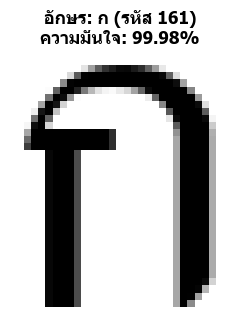

In [2]:
def predict_image(img_path, show=True):
    if not os.path.exists(img_path):
        print(f'ไม่พบไฟล์: {img_path}')
        return None
        
    img = Image.open(img_path).convert('RGB')
    tensors = [
        transform(img.rotate(angle, fillcolor=(255, 255, 255), resample=Image.BILINEAR)).unsqueeze(0).to(device)
        for angle in [-5, 0, 5]
    ]
    batch_x = torch.cat(tensors, dim=0)
    
    with torch.no_grad():
        probs = torch.softmax(model(batch_x), dim=1).mean(dim=0)
        
    best_idx = probs.argmax().item()
    code = str(idx_to_class[best_idx])
    confidence = probs[best_idx].item() * 100
    char = get_thai_char(code)
    
    print(f'ไฟล์: {os.path.basename(img_path)} -> ตัวอักษร: {char} | รหัสคลาส: {code} | ความมั่นใจ: {confidence:.2f}%')
    
    if show:
        plt.figure(figsize=(3.5, 3.5))
        plt.imshow(img)
        plt.axis('off')
        plt.title(f'อักษร: {char} (รหัส {code})\nความมั่นใจ: {confidence:.2f}%', fontsize=12, fontweight='bold')
        plt.show()
        
    return {'code': code, 'char': char, 'confidence': confidence}

# ตัวอย่างทดสอบภาพเดี่ยว
sample_img = 'test/161_1.png'
if os.path.exists(sample_img):
    predict_image(sample_img)


## 2. ทำนายผลจากไฟล์ test.csv และส่งออกไฟล์ out.csv


In [3]:
# ==========================================================
# ฟังก์ชันทำนายจาก test.csv และส่งออก out.csv พร้อมสรุป Accuracy
# ==========================================================
def predict_from_csv(csv_path='test/test.csv', img_dir='test', output_csv='out.csv', use_tta=True):
    if not os.path.exists(csv_path):
        for c in [csv_path, 'test/test.csv', 'test.csv']:
            if os.path.exists(c):
                csv_path = c
                break
        else:
            print(f'ไม่พบไฟล์: {csv_path}')
            return None

    if not os.path.exists(img_dir):
        img_dir = os.path.dirname(csv_path) or 'test'

    test_df = pd.read_csv(csv_path)
    id_col = 'id' if 'id' in test_df.columns else test_df.columns[0]

    predictions = []
    labeled_count = 0
    correct_count = 0
    valid_exts = ['', '.png', '.jpg', '.jpeg', '.bmp', '.webp', '.tiff', '.tif', '.PNG', '.JPG', '.JPEG', '.BMP', '.WEBP', '.TIFF']

    with torch.no_grad():
        for img_id in test_df[id_col]:
            str_id = str(img_id).strip()
            img_path = None
            for ext in valid_exts:
                p = os.path.join(img_dir, f'{str_id}{ext}')
                if os.path.exists(p):
                    img_path = p
                    break

            if img_path and os.path.exists(img_path):
                prefix = str_id.split('_')[0]
                true_code = prefix if prefix in classes_str else None

                img = Image.open(img_path).convert('RGB')
                if use_tta:
                    tensors = [
                        transform(img.rotate(angle, fillcolor=(255, 255, 255), resample=Image.BILINEAR)).unsqueeze(0).to(device)
                        for angle in [-5, 0, 5]
                    ]
                    probs = torch.softmax(model(torch.cat(tensors, dim=0)), dim=1).mean(dim=0, keepdim=True)
                else:
                    tensor = transform(img).unsqueeze(0).to(device)
                    probs = torch.softmax(model(tensor), dim=1)

                pred_idx = probs.argmax(dim=1).item()
                predicted_code = str(idx_to_class[pred_idx])
                label_val = int(predicted_code) if predicted_code.isdigit() else predicted_code
                predictions.append(label_val)

                if true_code is not None:
                    labeled_count += 1
                    if str(label_val) == str(true_code):
                        correct_count += 1
            else:
                predictions.append(None)

    # บันทึกไฟล์ out.csv
    out_df = pd.DataFrame({'id': test_df[id_col], 'label': predictions})
    out_df.to_csv(output_csv, index=False)

    # แสดงผลสรุป
    if labeled_count > 0:
        acc = (correct_count / labeled_count) * 100
        print(f' Accuracy: {acc:.2f}% (ถูกต้อง {correct_count:,}/{labeled_count:,} ภาพ)')
    print(f" บันทึกผลลัพธ์ลง '{output_csv}' เรียบร้อย")
    
    return out_df.head(10)

# สั่งประมวลผลและแสดงตัวอย่างผลลัพธ์ outXls.head()
predict_from_csv(csv_path='test/test.csv', img_dir='test', output_csv='out.csv', use_tta=True)


 Accuracy: 90.05% (ถูกต้อง 389/432 ภาพ)
 บันทึกผลลัพธ์ลง 'out.csv' เรียบร้อย


,id,label
0,161_1,161
1,161_2,161
2,161_3,164
3,161_4,161
4,161_5,161
5,161_6,161
6,162_1,162
7,162_2,162
8,162_3,162
9,162_4,162


## 3. แสดงตารางตัวอย่างการทำนาย (Visual Demo)


ไฟล์: 245_5.png -> ตัวอักษร: ๕ | รหัสคลาส: 245 | ความมั่นใจ: 98.85%
ไฟล์: 168_2.png -> ตัวอักษร: จ | รหัสคลาส: 168 | ความมั่นใจ: 80.84%
ไฟล์: 215_2.png -> ตัวอักษร: ื | รหัสคลาส: 215 | ความมั่นใจ: 96.23%
ไฟล์: 161_3.png -> ตัวอักษร: ค | รหัสคลาส: 164 | ความมั่นใจ: 57.21%
ไฟล์: 173_1.png -> ตัวอักษร: ญ | รหัสคลาส: 173 | ความมั่นใจ: 80.17%
ไฟล์: 232_5.png -> ตัวอักษร: า | รหัสคลาส: 210 | ความมั่นใจ: 72.06%
ไฟล์: 249_6.png -> ตัวอักษร: ส | รหัสคลาส: 202 | ความมั่นใจ: 93.49%
ไฟล์: 204_1.png -> ตัวอักษร: พ | รหัสคลาส: 190 | ความมั่นใจ: 84.11%


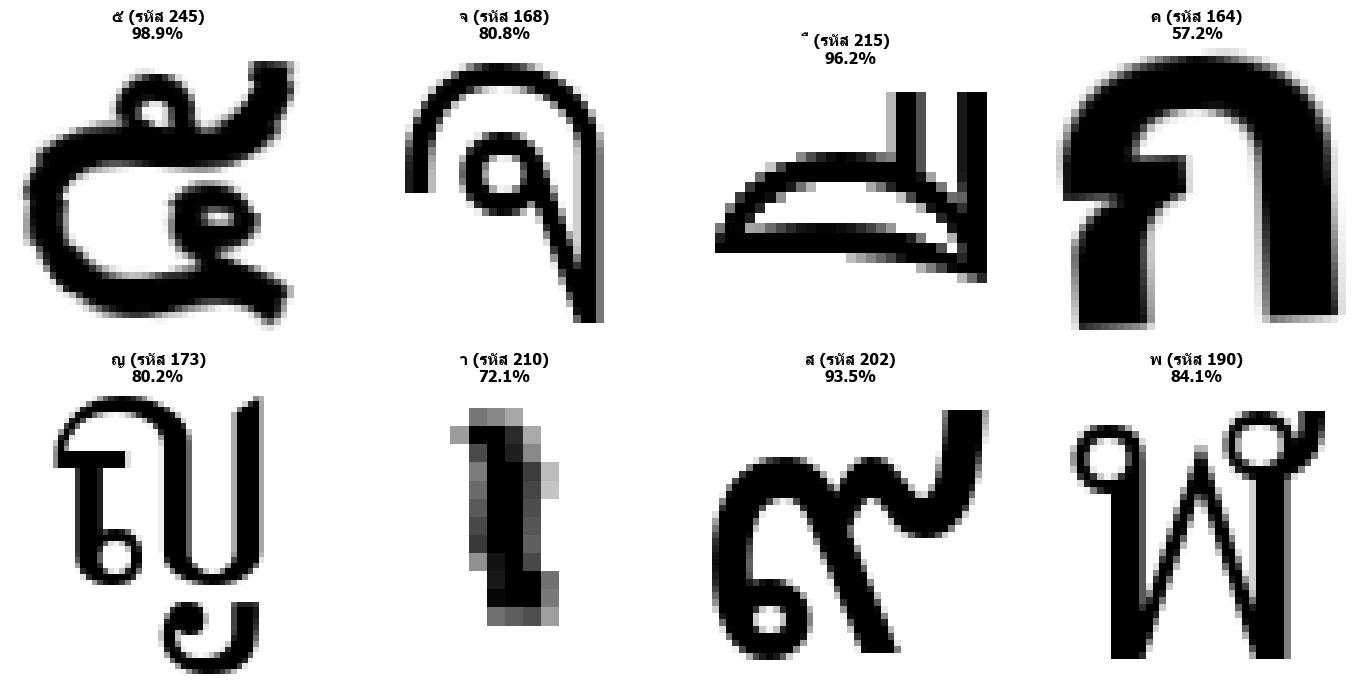

In [4]:
def show_demo(folder_path='test', n=8):
    if not os.path.exists(folder_path):
        print(f'ไม่พบโฟลเดอร์: {folder_path}')
        return
        
    valid_exts = ('.jpg', '.jpeg', '.png', '.bmp', '.webp', '.tiff', '.tif')
    files = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if f.lower().endswith(valid_exts)]
    if not files:
        print(f'ไม่พบรูปภาพใน: {folder_path}')
        return
        
    import random
    sample_files = random.sample(files, min(n, len(files)))
    
    cols = 4
    rows = int(np.ceil(len(sample_files) / cols))
    plt.figure(figsize=(cols * 3.5, rows * 3.5))
    
    for i, fp in enumerate(sample_files):
        res = predict_image(fp, show=False)
        img = Image.open(fp).convert('RGB')
        
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"{res['char']} (รหัส {res['code']})\n{res['confidence']:.1f}%", fontsize=11, fontweight='bold')
        
    plt.tight_layout()
    plt.show()

# เรียกแสดงตัวอย่างการทำนาย
if os.path.exists('test'):
    show_demo('test', n=8)
